In [1]:
# Cell 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

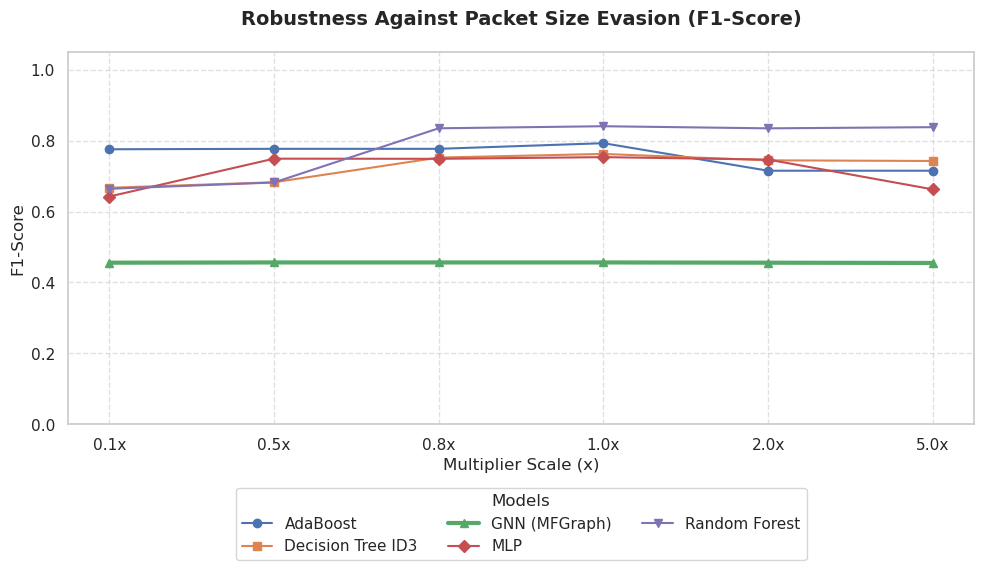

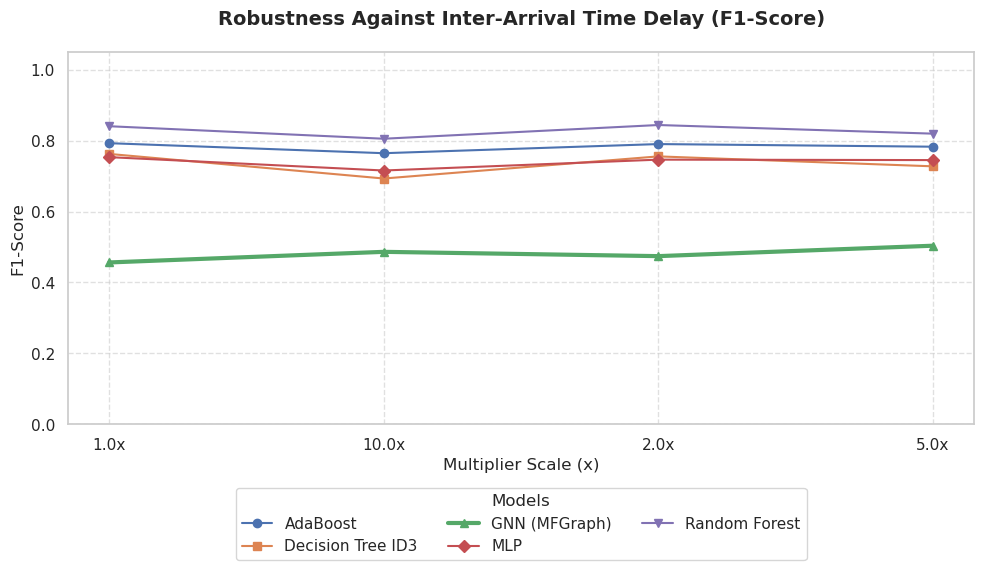

In [6]:
# Cell 2: Plot NIDS Adversarial Evasion (Unified Results)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_nids_adversarial(csv_filename, title, xlabel):
    project_root = Path().resolve().parents[0]
    
    # Directory where the unified robustness CSVs are saved
    adv_dir = project_root / "experiments" / "nids_adversarial"
    path_csv = adv_dir / csv_filename
    
    if not path_csv.exists():
        print(f"[Error] File not found: {path_csv}")
        return
        
    # Load the combined CSV (contains both baselines and GNN)
    df = pd.read_csv(path_csv, index_col=0)
    
    # Ensure index is string for categorical plotting on the X-axis
    df.index = df.index.astype(str)
    
    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*']
    
    for idx, col in enumerate(df.columns):
        # Dynamically highlight GNN-NIDS / MFGraph with a thicker line
        is_gnn = "GNN" in str(col) or "MFGraph" in str(col)
        linewidth = 3.0 if is_gnn else 1.5
        
        ax1.plot(
            df.index, 
            df[col], 
            marker=markers[idx % len(markers)], 
            linewidth=linewidth, 
            label=col
        )
        
    ax1.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax1.set_xlabel(xlabel, fontsize=12)
    ax1.set_ylabel("F1-Score", fontsize=12)
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, linestyle="--", alpha=0.6)
    
    # Extract legend handles and put them below the plot
    lines, labels = ax1.get_legend_handles_labels()
    ax1.legend(lines, labels, title="Models", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    fig.tight_layout()
    plt.show()

# Plot Packet Size Evasion (F1-Score)
plot_nids_adversarial(
    csv_filename="Packet Size_robustness.csv", 
    title="Robustness Against Packet Size Evasion (F1-Score)",
    xlabel="Multiplier Scale (x)"
)

# Plot Inter-Arrival Time Evasion (F1-Score)
plot_nids_adversarial(
    csv_filename="Inter-Arrival Time_robustness.csv", 
    title="Robustness Against Inter-Arrival Time Delay (F1-Score)",
    xlabel="Multiplier Scale (x)"
)

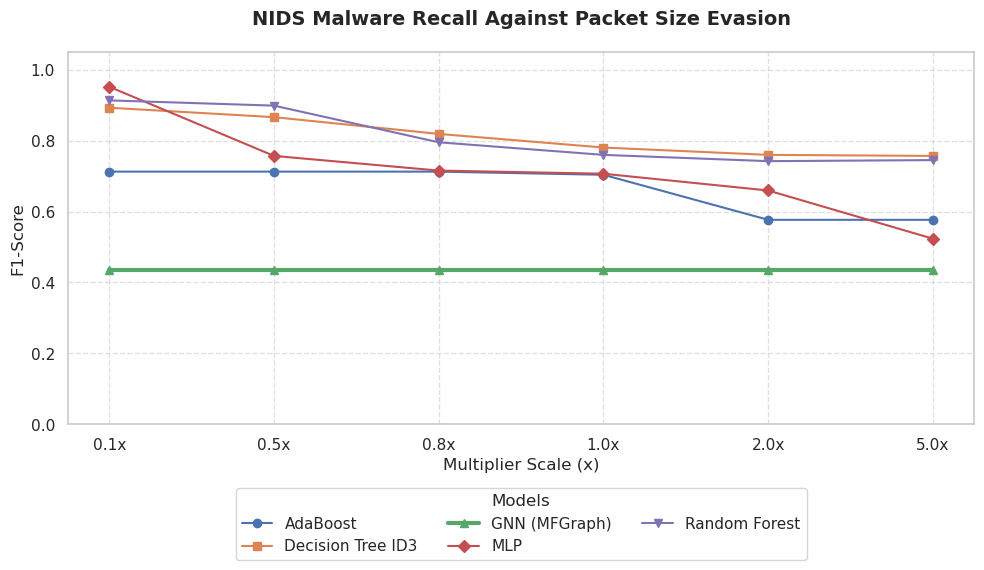

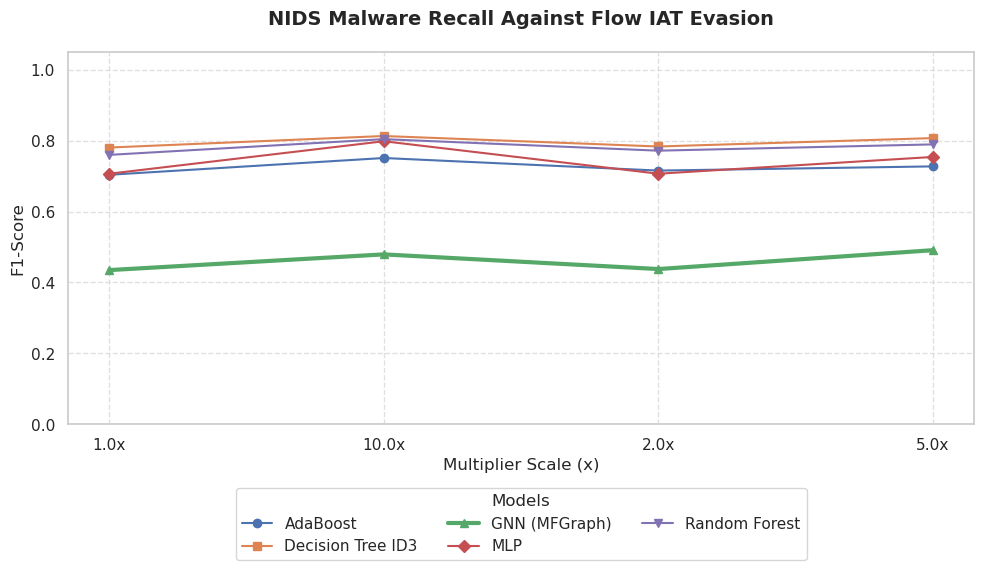

In [16]:
# Cell 4: Plot NIDS Malware Recall Degradation
# Uses the function we defined in the previous cell!

# Plot Packet Size Evasion (Recall)
plot_nids_adversarial(
    csv_filename="Packet Size_recall.csv", 
    title="NIDS Malware Recall Against Packet Size Evasion",
    xlabel="Multiplier Scale (x)"
)

# Plot Inter-Arrival Time Evasion (Recall)
plot_nids_adversarial(
    csv_filename="Inter-Arrival Time_recall.csv", 
    title="NIDS Malware Recall Against Flow IAT Evasion",
    xlabel="Multiplier Scale (x)"
)

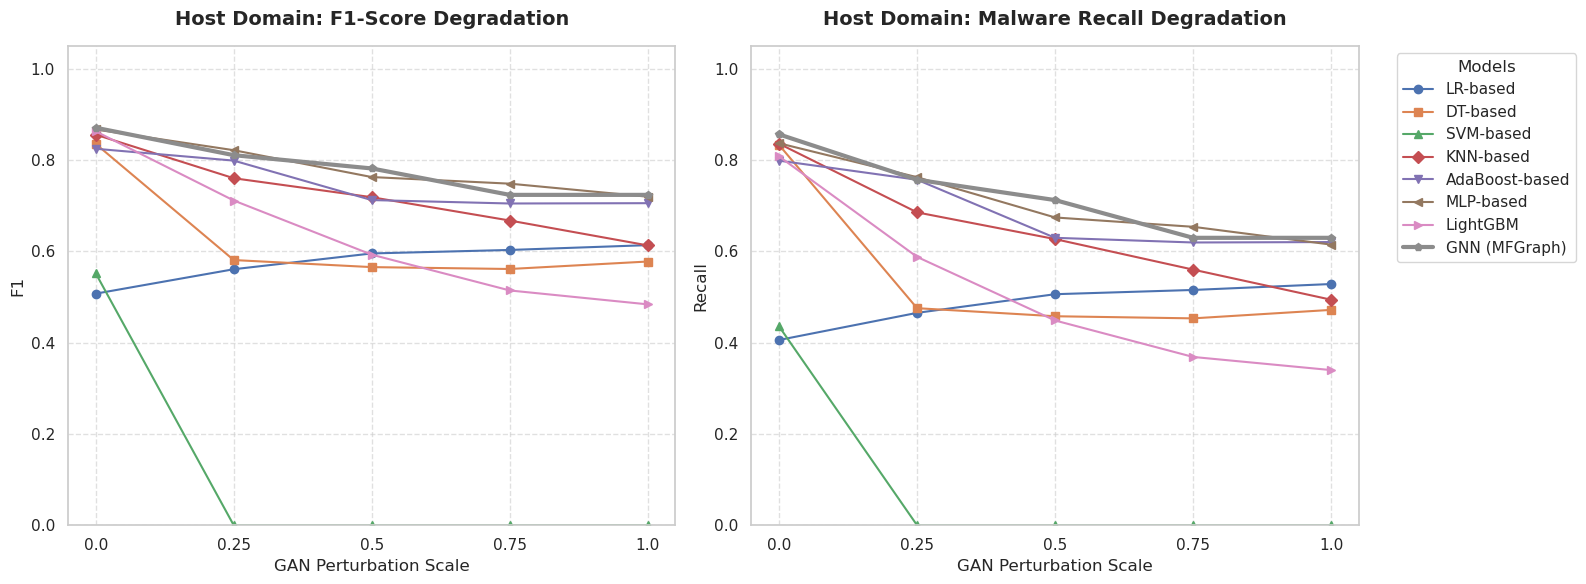

In [17]:
# Cell 5: PE compares (F1-Score and Recall)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_filename = "GAN_Evasion_multimetric.csv"
path = Path().resolve().parents[0] / "experiments" / "pe_adversarial" / csv_filename

if not path.exists():
    print(f"File not found: {path}")
    print("Ensure you have run 'python orchestrator.py -t eval_pe_adversarial' first.")
else:
    df = pd.read_csv(path)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*']
    
    models = df['Model'].unique()
    
    for ax, metric, title in zip(axes, ['F1', 'Recall'], 
                                 ['Host Domain: F1-Score Degradation', 'Host Domain: Malware Recall Degradation']):
        for idx, model in enumerate(models):
            model_data = df[df['Model'] == model]
            
            # Dynamically highlight the GNN line to match NIDS plot styling
            is_gnn = "GNN" in str(model) or "MFGraph" in str(model)
            linewidth = 3.0 if is_gnn else 1.5
            
            ax.plot(
                model_data['Scale'].astype(str), 
                model_data[metric], 
                marker=markers[idx % len(markers)], 
                linewidth=linewidth, 
                label=model
            )
            
        ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel("GAN Perturbation Scale", fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle="--", alpha=0.6)
        
    # Add legend only to the right plot (Recall) to save space
    axes[1].legend(title="Models", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()